

# DTR RFR GBR Boston Housing
### OPIM 5512 — Applied Data Science · Module1

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5512-notebooks/blob/main/Module1/DTR_RFR_GBR_BostonHousing.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Tree-Based Models with GBR Hyperparameter Tuning
---------------------------------------
**Dr. Dave Wanik - University of Connecticut**

All I've done is paste in the other 'blackbox' models - let it rip!!! Then go explore the different hyperparameters that are available to you for tuning.

## Getting started
Import modules, mount Drive, read in the data, check data types and missing values. You may also do some light EDA prior to modeling.

Notice how we are using the same functions over and over again... it really is like following a recipe.


In [ ]:
# import modules we need for EDA and wrangling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# these functions are useful for splitting and normalization
from sklearn.preprocessing import  MinMaxScaler
from sklearn.model_selection import train_test_split

# import other functions we'll need for regression modeling
from sklearn.linear_model import LinearRegression # LR
from sklearn.tree import DecisionTreeRegressor # DTR
from sklearn.ensemble import RandomForestRegressor # RFR
from sklearn.ensemble import GradientBoostingRegressor #GBR

# regression error metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# mount your google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# read in some data
df = pd.read_csv('/content/drive/MyDrive/Online Materials - Data Science /Module 3: Tree-Based Methods/Week 1: DTR and RFR from Scratch/data/Boston Housing.csv')

In [ ]:
# data type, shape and columns

print("This is the shape :\n", df.shape, '\n') # escape characters are fun! \n adds a return line
print("These are the column names: \n", df.columns, '\n') # helps keep things nice and clean
print("These are the data types: \n", df.dtypes)

# right away you see this 'valid' column is an 'object', which means it's a string
# AKA something you can't do math on... look at the head and see what's going on
# in that column. ALL OTHER DATA IS NUMERIC (float64)
# this is a good quiz question... ;)

print("\nThis is the head:") # see how I can pop that \n anywhere?
df.head()   # also note how much stuff I have pasted in ONE CELL...
            # now you are cooking with gas!

# the head confirms to use that the valid column is some type of time/date stamp
# we need to stop what we are doing and take care of this NOW!

This is the shape :
 (506, 14) 

These are the column names: 
 Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object') 

These are the data types: 
 crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

This is the head:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
# here's another cool way to get a lot of this info AND MORE
df.info() # gives you missing values report too - this is nice complete data

# data types, shape, missing values per columm.... pandas rocks...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


## Data splitting
Subset your data into X features and Y target variable for modeling. Convert X and Y to numpy arrays. Then use train_test_split for data splitting (80/20 is very common); don't forget random seed and shuffle.

In [ ]:
# the target variable is Y
# we know that this is 'medv'
Y = df['medv']
print(Y.shape) # a single column with 506 rows

(506,)


In [ ]:
# everything else is X
# so just drop 'medv' and you are done
X = df.drop('medv', axis=1)
print(X.shape) # note that we have gone from 14 to 13 columns, this is good! 506 rows.

(506, 13)


In [ ]:
# now, split the data in ONE LINE OF CODE
# notice how we are assigning four different variables at once
# this makes it really clean

# be careful of capital vs. lowercase X and Y, you might get an error...
# notice the 80/20 split we perform

X_train, X_test, y_train, y_test = train_test_split(X, Y,
                                                    test_size = 0.2,
                                                    shuffle = True,
                                                    random_state = 42)

In [ ]:
# check your work - does the shape match what you think it should be?
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(404, 13) (102, 13) (404,) (102,)


In [ ]:
# # convert these all to numpy arrays
# X_train = np.array(X_train)
# X_test = np.array(X_test)
# y_train = np.array(y_train)
# y_test = np.array(y_test)

## Min/Max Scaling
This will ensure all of your X data is between 0 (min) and 1 (max). You will use fit_transform() on the train data first, then fit on the test data. If you don't do this step after splitting, you will have data leakage.

Only scale the X data, not the Y data!

Do yourself a favor and just overwrite X_train and X_test when standardizing, as I do below. Min/max scaling requires that the data are numpy arrays and all numeric data.


**Like this example:**
```
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
```


In [ ]:
# you probably have already imported the MinMaxScale at the top of your script
# you should convert to numpy array before scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# if you wanted to run summary stats on these to check the range,
# you would need to convert to a pandas dataframe.
tmp = pd.DataFrame(X_train)
tmp.describe() # notice how all the max values are 1, all min values are 0.

,0,1,2,3,4,5,6,7,8,9,10,11,12
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,0.040465,0.115693,0.379446,0.071782,0.352848,0.498859,0.676173,0.243577,0.363323,0.414184,0.608332,0.897570,0.296009
std,0.099757,0.231525,0.255356,0.258447,0.242190,0.144285,0.288310,0.193802,0.373466,0.317123,0.237096,0.230890,0.196203
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000814,0.000000,0.162593,0.000000,0.137860,0.412345,0.439238,0.087140,0.130435,0.175573,0.446809,0.945969,0.139142
50%,0.002836,0.000000,0.289630,0.000000,0.314815,0.477324,0.770340,0.186066,0.173913,0.272901,0.648936,0.985892,0.253725
75%,0.035900,0.200000,0.642963,0.000000,0.506173,0.564114,0.934604,0.388400,0.478261,0.914122,0.808511,0.997113,0.404042
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# if you wanted to run summary stats on these to check the range,
# you would need to convert to a pandas dataframe.
tmp = pd.DataFrame(X_test)
tmp.describe() # notice how all the max values are 1, all min values are 0.

,0,1,2,3,4,5,6,7,8,9,10,11,12
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,0.040710,0.105490,0.407324,0.058824,0.334586,0.467324,0.677117,0.237644,0.404945,0.453993,0.680747,0.902520,0.322799
std,0.083847,0.240832,0.248984,0.236456,0.223462,0.135006,0.297537,0.182847,0.398343,0.338669,0.191551,0.228559,0.199906
min,-0.000031,0.000000,-0.010370,0.000000,0.014403,-0.061420,0.033986,0.003592,0.000000,0.001908,0.042553,0.016037,0.031733
25%,0.000880,0.000000,0.198611,0.000000,0.130144,0.408227,0.421215,0.103152,0.130435,0.180821,0.617021,0.944828,0.164390
50%,0.002257,0.000000,0.364815,0.000000,0.302469,0.469290,0.739444,0.202221,0.173913,0.301527,0.702128,0.988161,0.292632
75%,0.050731,0.000000,0.642963,0.000000,0.486626,0.532083,0.950824,0.330568,1.000000,0.914122,0.808511,1.000000,0.449434
max,0.514089,0.950000,1.000000,1.000000,1.000000,0.848281,1.000000,0.871218,1.000000,1.000000,1.000000,1.000000,0.972682


## Fit The Model
Fit the model and make new variables to save your train and test predictions. Make sure you are using the appropriate regression or classification model.

Notice how we're using the same training data and test data for each model - this is critical!

Also note that in many StackOverflow examples, folks don't use 'DTR' or 'LR' as variable names for their models - instead, they often use 'clf' which stands for classifier. Helps you abstract what's going on.

### Linear Regression

In [ ]:
# make a variable to store the general model
LR = LinearRegression()
# fit the model - one line of code
LR = LR.fit(X_train, y_train)

In [ ]:
# store the predictions
train_preds_LR = LR.predict(X_train)
test_preds_LR = LR.predict(X_test)

### DTR

Check out the model documentation:

**DTR Model Documentation:** https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html


Some extra content to think about...

**Link:** https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html

**Link:** https://scikit-learn.org/stable/modules/tree.html

In [ ]:
# make a variable to store the general model
# you can accept all of the defaults...
DTR = DecisionTreeRegressor()
# or start to 'tinker' :) this is called hyperparameter tuning
# DTR = DecisionTreeRegressor(min_samples_split=15) # make this bigger and the tree will shrink!

# fit the model - one line of code
DTR = DTR.fit(X_train, y_train)

In [ ]:
# store the predictions
train_preds_DTR = DTR.predict(X_train)
test_preds_DTR = DTR.predict(X_test)

In [ ]:
from sklearn.tree import export_graphviz
from io import StringIO # Changed import from sklearn.externals.six to io
from IPython.display import Image
import pydotplus

dot_data = StringIO()
export_graphviz(DTR, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

# hard to see, but that's OK!
# we will learn about partial depenence
# and feature importance with is way easier to see than this

# for now, just appreciate how awesome this looks!
# double click and you can see

Output hidden; open in https://colab.research.google.com to view.

**Figure 1:** A printout of the rules learned by the DTR.

### RFR
Random Forest Regressor

In [ ]:
# make a variable to store the general model
# you can accept all of the defaults...
RFR = RandomForestRegressor()
# or start to 'tinker' :) this is called hyperparameter tuning
# DTR = DecisionTreeRegressor(min_samples_split=15) # make this bigger and the tree will shrink!

# fit the model - one line of code
RFR = RFR.fit(X_train, y_train)

In [ ]:
# store the predictions
train_preds_RFR = RFR.predict(X_train)
test_preds_RFR = RFR.predict(X_test)

### GBR
Let's add the Gradient Boosting model!

In [ ]:
# make a variable to store the general model
# you can accept all of the defaults...
GBR = GradientBoostingRegressor()

# fit the model - one line of code
GBR = GBR.fit(X_train, y_train)

# store the predictions
train_preds_GBR = GBR.predict(X_train)
test_preds_GBR = GBR.predict(X_test)

## Evaluate the Model
Look at the appropriate error metrics depending on the problem you are solving.

For a regression problem, look at the R2, MAE and MSE; then make a scatterplot of actual vs. predicted values with nice labels and titles.

For a classification problem, create the classification report (gives a confusion matrix and useful metrics in one line of code).

See how we are just tacking on a suffix like '_LR' or '_DTR' on the end of things? Keep your code clean and you can just copy paste. Same stuff as before, but we need to be organized since we are introducing more models.

### R2
Out of all of these, random forest is the most believable! Did not memorize the training data and has consistent results between train and test results. In practice - we only really care about the test results.

In [ ]:
# this is a regression problem, and there are three metrics to look at.
# 1) R2 value - for Linear Regression
print("This is train R2 (LR):", r2_score(y_train, train_preds_LR)) # train
print("This is test R2 (LR):", r2_score(y_test, test_preds_LR)) # test

# 1) R2 value - for Decision Tree Regression
print("This is train R2 (DTR):", r2_score(y_train, train_preds_DTR)) # train
print("This is test R2 (DTR):", r2_score(y_test, test_preds_DTR)) # test

# 1) R2 value - for Random Forest Regression
print("This is train R2 (RFR):", r2_score(y_train, train_preds_RFR)) # train
print("This is test R2 (RFR):", r2_score(y_test, test_preds_RFR)) # test

# 1) R2 value - for Gradient Boosting Regression
print("This is train R2 (GBR):", r2_score(y_train, train_preds_GBR)) # train
print("This is test R2 (GBR):", r2_score(y_test, test_preds_GBR)) # test

This is train R2 (LR): 0.7508856358979673
This is test R2 (LR): 0.6687594935356322
This is train R2 (DTR): 1.0
This is test R2 (DTR): 0.8711264589600661
This is train R2 (RFR): 0.97727680732005
This is test R2 (RFR): 0.8738648948362852
This is train R2 (GBR): 0.9800300447996301
This is test R2 (GBR): 0.9138329233573605


### MAE
Again, RFR is the champ here - best test results!

In [ ]:
# 2) mae - for Linear Regression
trainMAE_LR = mean_absolute_error(y_train, train_preds_LR)
print("This is trainMAE (LR):", trainMAE_LR) # train
testMAE_LR = mean_absolute_error(y_test, test_preds_LR)
print("This is testMAE (LR):", testMAE_LR) # test

# 2) mae - for DT Regression
trainMAE_DTR = mean_absolute_error(y_train, train_preds_DTR)
print("This is trainMAE (DTR):", trainMAE_DTR) # train
testMAE_DTR = mean_absolute_error(y_test, test_preds_DTR)
print("This is testMAE (DTR):", testMAE_DTR) # test

# 2) mae - for RF Regression
trainMAE_RFR = mean_absolute_error(y_train, train_preds_RFR)
print("This is trainMAE (RFR):", trainMAE_RFR) # train
testMAE_RFR = mean_absolute_error(y_test, test_preds_RFR)
print("This is testMAE (RFR):", testMAE_RFR) # test

# 2) mae - for GB Regression
trainMAE_GBR = mean_absolute_error(y_train, train_preds_GBR)
print("This is trainMAE (GBR):", trainMAE_GBR) # train
testMAE_GBR = mean_absolute_error(y_test, test_preds_GBR)
print("This is testMAE (GBR):", testMAE_GBR) # test

This is trainMAE (LR): 3.314771626783231
This is testMAE (LR): 3.189091965887846
This is trainMAE (DTR): 0.0
This is testMAE (DTR): 2.201960784313725
This is trainMAE (RFR): 0.8880247524752471
This is testMAE (RFR): 2.1018039215686275
This is trainMAE (GBR): 1.0438163652602068
This is testMAE (GBR): 1.9189179516128536


### MSE
If you see an MSE of 0, this means a perfect prediction - this should NEVER happen... there should always be at least a little bit of error in your train results, otherwise you are OVERFITTING. You need to play with the hyperparameters (we will do this in future weeks).

In [ ]:
# 3) mse
trainMSE_LR = mean_squared_error(y_train, train_preds_LR)
print("This is trainMSE (LR):", trainMSE_LR)
testMSE_LR = mean_squared_error(y_test, test_preds_LR)
print("This is testMSE (LR):", testMSE_LR)

# 3) mse
trainMSE_DTR = mean_squared_error(y_train, train_preds_DTR)
print("This is trainMSE (DTR):", trainMSE_DTR)
testMSE_DTR = mean_squared_error(y_test, test_preds_DTR)
print("This is testMSE (DTR):", testMSE_DTR)

# 3) mse
trainMSE_RFR = mean_squared_error(y_train, train_preds_RFR)
print("This is trainMSE (RFR):", trainMSE_RFR)
testMSE_RFR = mean_squared_error(y_test, test_preds_RFR)
print("This is testMSE (RFR):", testMSE_RFR)

# 3) mse
trainMSE_GBR = mean_squared_error(y_train, train_preds_GBR)
print("This is trainMSE (GBR):", trainMSE_GBR)
testMSE_GBR = mean_squared_error(y_test, test_preds_GBR)
print("This is testMSE (GBR):", testMSE_GBR)

This is trainMSE (LR): 21.641412753226312
This is testMSE (LR): 24.291119474973502
This is trainMSE (DTR): 0.0
This is testMSE (DTR): 9.450784313725489
This is trainMSE (RFR): 1.974041094059406
This is testMSE (RFR): 9.249964450980398
This is trainMSE (GBR): 1.734857982647807
This is testMSE (GBR): 6.318957714070252


## LR predictions
This is a simpler model, and it has different error than the Decision Tree model!

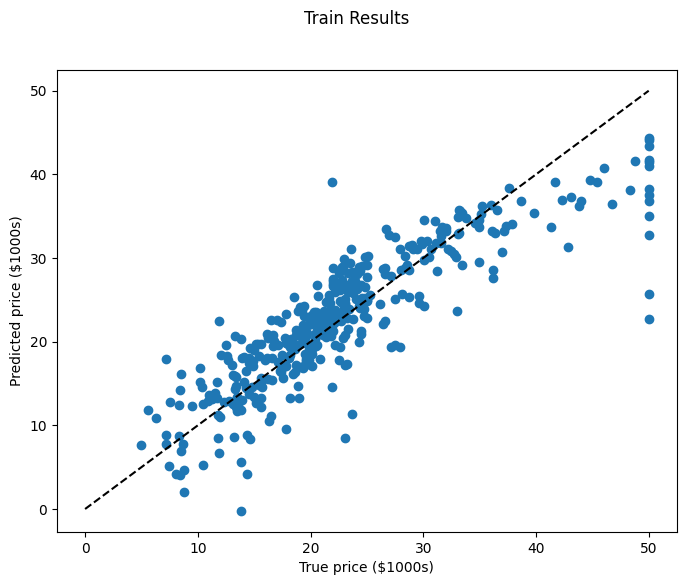

In [ ]:
# a quick scatterplot for train results
# let's see how it fit
plt.figure(figsize=(8, 6))
plt.scatter(x=y_train, y=train_preds_LR)
plt.plot([0, 50], [0, 50], '--k') # 45 degree line
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')
plt.suptitle('Train Results')
plt.show()

**Figure 2:** A scatterplot of actual vs pred for the LR on train partition.

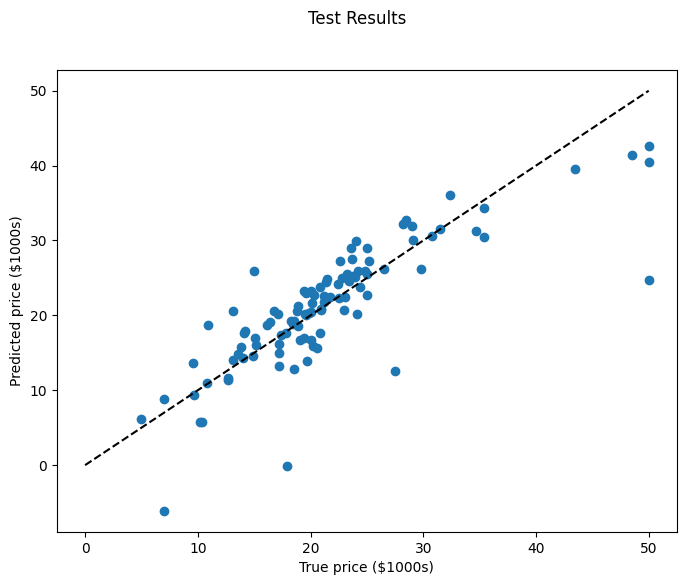

In [ ]:
# a quick scatterplot for test results
# same code as above, just different labels
# a quick scatterplot for train results
# let's see how it fit
plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=test_preds_LR)
plt.plot([0, 50], [0, 50], '--k') # 45 degree line
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')
plt.suptitle('Test Results')
plt.show()

**Figure 3:** A scatterplot of actual vs pred for the DTR on test partition.

## DTR Results
Look at how each has a different flavor...

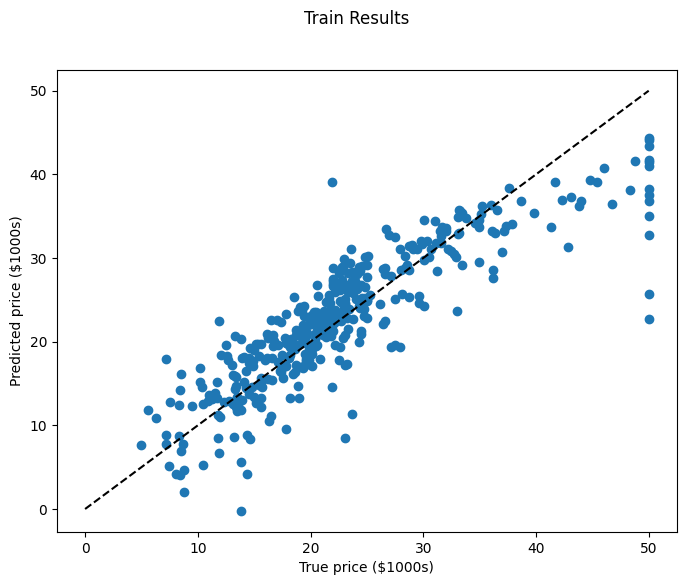

In [ ]:
# a quick scatterplot for train results
# let's see how it fit
plt.figure(figsize=(8, 6))
plt.scatter(x=y_train, y=train_preds_LR)
plt.plot([0, 50], [0, 50], '--k') # 45 degree line
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')
plt.suptitle('Train Results')
plt.show()

**Figure 4:** A scatterplot of actual vs pred for the DTR on train.

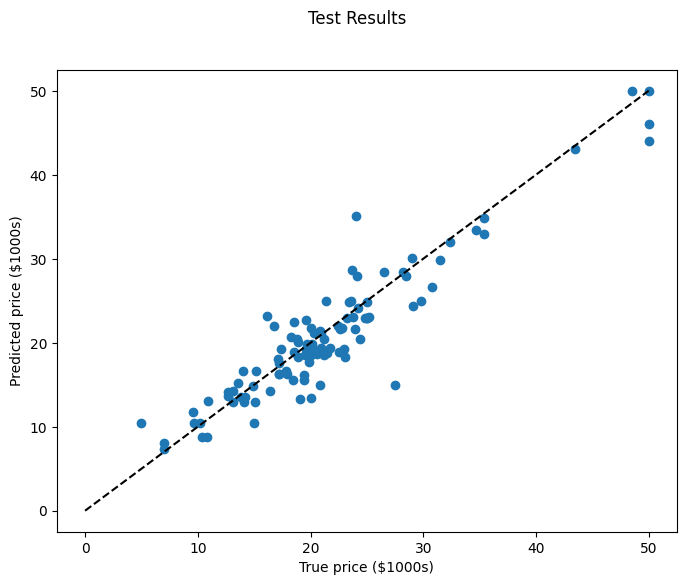

In [ ]:
# a quick scatterplot for test results
# same code as above, just different labels
# a quick scatterplot for train results
# let's see how it fit
plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=test_preds_DTR)
plt.plot([0, 50], [0, 50], '--k') # 45 degree line
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')
plt.suptitle('Test Results')
plt.show()

**Figure 6:** A scatterplot of actual vs pred for the DTR on test.

## Sub-Plots
Way cleaner! Try doing the plots side-by-side.

### LR Results

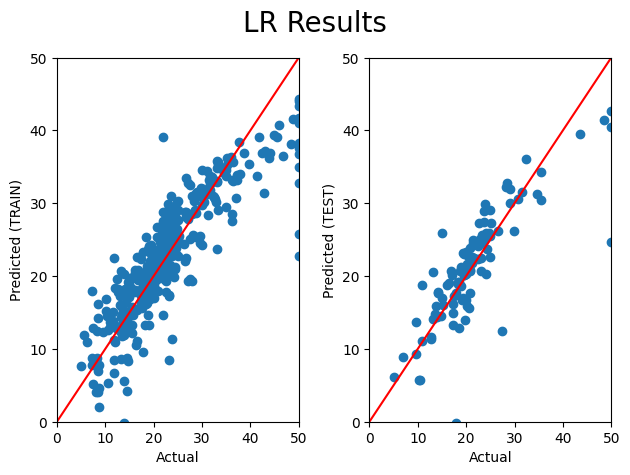

In [ ]:
# specify the dimensions
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# fig limits


# add a main title across top
fig.suptitle("LR Results", fontsize=20)

# this makes the individual subplots
axes[0].scatter(x=y_train, y=train_preds_LR) #first row, first entry (left top)
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted (TRAIN)",  fontsize=10)
# set plot limits
axes[0].set_xlim(0,50)
axes[0].set_ylim(0,50)
# add 45 degree line to left panel
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')


axes[1].scatter(x=y_test, y=test_preds_LR) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted (TEST)",  fontsize=10)
# set plot limits
axes[1].set_xlim(0,50)
axes[1].set_ylim(0,50)
# add 45 degree line to right panel
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# scooch it down
# link: https://stackoverflow.com/questions/7066121/how-to-set-a-single-main-title-above-all-the-subplots-with-pyplot
fig.subplots_adjust(top=0.88)

# show the plot
plt.show()

**Figure 7:** A two-panel scatterplot of actual vs pred for the LR.

### DTR Results

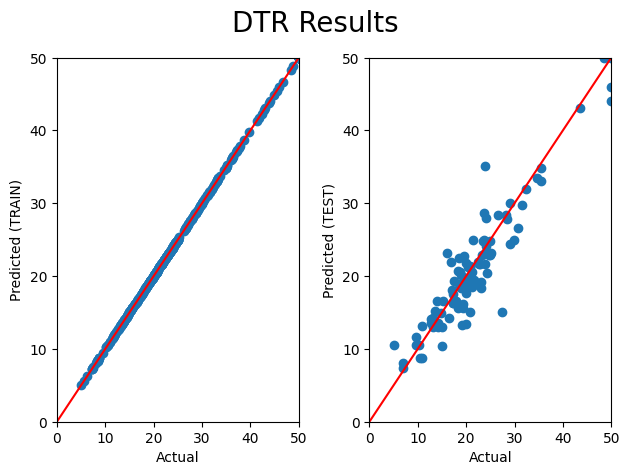

In [ ]:
# specify the dimensions
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# fig limits


# add a main title across top
fig.suptitle("DTR Results", fontsize=20)

# this makes the individual subplots
axes[0].scatter(x=y_train, y=train_preds_DTR) #first row, first entry (left top)
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted (TRAIN)",  fontsize=10)
# set plot limits
axes[0].set_xlim(0,50)
axes[0].set_ylim(0,50)
# add 45 degree line to left panel
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')


axes[1].scatter(x=y_test, y=test_preds_DTR) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted (TEST)",  fontsize=10)
# set plot limits
axes[1].set_xlim(0,50)
axes[1].set_ylim(0,50)
# add 45 degree line to right panel
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# scooch it down
# link: https://stackoverflow.com/questions/7066121/how-to-set-a-single-main-title-above-all-the-subplots-with-pyplot
fig.subplots_adjust(top=0.88)

# show the plot
plt.show()

**Figure 8:** A two-panel scatterplot of actual vs pred for the DTR.

### RFR Results

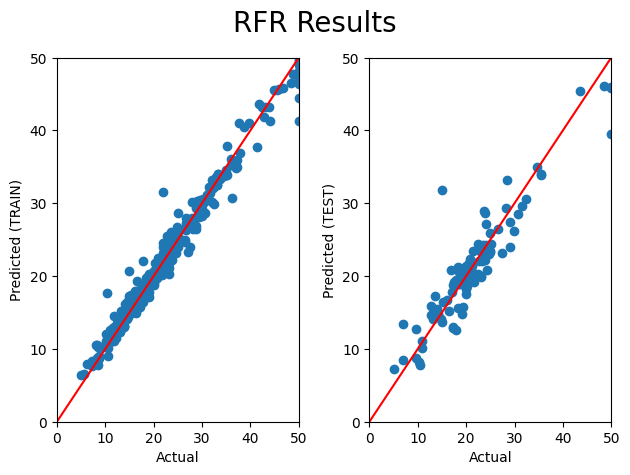

In [ ]:
# specify the dimensions
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# fig limits


# add a main title across top
fig.suptitle("RFR Results", fontsize=20)

# this makes the individual subplots
axes[0].scatter(x=y_train, y=train_preds_RFR) #first row, first entry (left top)
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted (TRAIN)",  fontsize=10)
# set plot limits
axes[0].set_xlim(0,50)
axes[0].set_ylim(0,50)
# add 45 degree line to left panel
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')


axes[1].scatter(x=y_test, y=test_preds_RFR) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted (TEST)",  fontsize=10)
# set plot limits
axes[1].set_xlim(0,50)
axes[1].set_ylim(0,50)
# add 45 degree line to right panel
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# scooch it down
# link: https://stackoverflow.com/questions/7066121/how-to-set-a-single-main-title-above-all-the-subplots-with-pyplot
fig.subplots_adjust(top=0.88)

# show the plot
plt.show()

**Figure 9:** A two-panel scatterplot of actual vs pred for the RFR.

### GBR Results

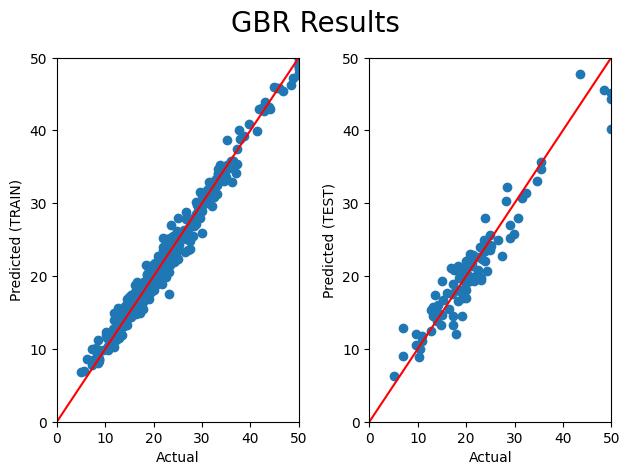

In [ ]:
# specify the dimensions
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# fig limits


# add a main title across top
fig.suptitle("GBR Results", fontsize=20)

# this makes the individual subplots
axes[0].scatter(x=y_train, y=train_preds_GBR) #first row, first entry (left top)
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted (TRAIN)",  fontsize=10)
# set plot limits
axes[0].set_xlim(0,50)
axes[0].set_ylim(0,50)
# add 45 degree line to left panel
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')


axes[1].scatter(x=y_test, y=test_preds_GBR) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted (TEST)",  fontsize=10)
# set plot limits
axes[1].set_xlim(0,50)
axes[1].set_ylim(0,50)
# add 45 degree line to right panel
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# scooch it down
# link: https://stackoverflow.com/questions/7066121/how-to-set-a-single-main-title-above-all-the-subplots-with-pyplot
fig.subplots_adjust(top=0.88)

# show the plot
plt.show()

**Figure 10:** A two-panel scatterplot of actual vs pred for the GBR.

# Done!
The DTR model overfits the training data a little bit, but we will let that be for now. The RFR model seems to do better - it actually learned to generalize the info from the train results and make a more stable test prediction.

As before, if you want, try updating some of the hyperparameters so that you get a little more scatter along the 45 degree line. For a DTR, you may consider


*   min_samples_leaf
*   min_samples_split

For example, by making min_samples_leaf = 15, you force the terminal nodes/leafs to have 15 rows in them, instead of 1! This is much more robust.

Check slides and model documentation for other ideas!



# GBR Hyperparameters
Look at all of the options that are available to you!

**loss**{‘ls’, ‘lad’, ‘huber’, ‘quantile’}, default=’ls’
Loss function to be optimized. ‘ls’ refers to least squares regression. ‘lad’ (least absolute deviation) is a highly robust loss function solely based on order information of the input variables. ‘huber’ is a combination of the two. ‘quantile’ allows quantile regression (use alpha to specify the quantile).

**learning_rate** float, default=0.1
Learning rate shrinks the contribution of each tree by learning_rate. There is a trade-off between learning_rate and n_estimators.

**n_estimators** int, default=100
The number of boosting stages to perform. Gradient boosting is fairly robust to over-fitting so a large number usually results in better performance.

**subsample** float, default=1.0
The fraction of samples to be used for fitting the individual base learners. If smaller than 1.0 this results in Stochastic Gradient Boosting. subsample interacts with the parameter n_estimators. Choosing subsample < 1.0 leads to a reduction of variance and an increase in bias.

**criterion**{‘friedman_mse’, ‘mse’, ‘mae’}, default=’friedman_mse’
The function to measure the quality of a split. Supported criteria are “friedman_mse” for the mean squared error with improvement score by Friedman, “mse” for mean squared error, and “mae” for the mean absolute error. The default value of “friedman_mse” is generally the best as it can provide a better approximation in some cases.

**min_samples_split** int or float, default=2
The minimum number of samples required to split an internal node:

If int, then consider min_samples_split as the minimum number.

If float, then min_samples_split is a fraction and ceil(min_samples_split * n_samples) are the minimum number of samples for each split.

**min_samples_leaf** int or float, default=1
The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.

If int, then consider min_samples_leaf as the minimum number.

If float, then min_samples_leaf is a fraction and ceil(min_samples_leaf * n_samples) are the minimum number of samples for each node.

**min_weight_fraction_leaf** float, default=0.0
The minimum weighted fraction of the sum total of weights (of all the input samples) required to be at a leaf node. Samples have equal weight when sample_weight is not provided.

**max_depth** int, default=3
Maximum depth of the individual regression estimators. The maximum depth limits the number of nodes in the tree. Tune this parameter for best performance; the best value depends on the interaction of the input variables.

**min_impurity_decrease** float, default=0.0
A node will be split if this split induces a decrease of the impurity greater than or equal to this value.

**random_state** int, RandomState instance or None, default=None
Controls the random seed given to each Tree estimator at each boosting iteration. In addition, it controls the random permutation of the features at each split (see Notes for more details). It also controls the random spliting of the training data to obtain a validation set if n_iter_no_change is not None. Pass an int for reproducible output across multiple function calls. See Glossary.

**max_features**{‘auto’, ‘sqrt’, ‘log2’}, int or float, default=None
The number of features to consider when looking for the best split:

* If int, then consider max_features features at each split.

* If float, then max_features is a fraction and int(max_features * n_features) features are considered at each split.

* If “auto”, then max_features=n_features.

* If “sqrt”, then max_features=sqrt(n_features).

* If “log2”, then max_features=log2(n_features).

* If None, then max_features=n_features.

**alpha** float, default=0.9
The alpha-quantile of the huber loss function and the quantile loss function. Only if loss='huber' or loss='quantile'.

**max_leaf_nodes** int, default=None
Grow trees with max_leaf_nodes in best-first fashion. Best nodes are defined as relative reduction in impurity. If None then unlimited number of leaf nodes.

**warm_start** bool, default=False
When set to True, reuse the solution of the previous call to fit and add more estimators to the ensemble, otherwise, just erase the previous solution. See the Glossary.

**validation_fraction** float, default=0.1
The proportion of training data to set aside as validation set for early stopping. Must be between 0 and 1. Only used if n_iter_no_change is set to an integer.

New in version 0.20.

**n_iter_no_change** int, default=None
n_iter_no_change is used to decide if early stopping will be used to terminate training when validation score is not improving. By default it is set to None to disable early stopping. If set to a number, it will set aside validation_fraction size of the training data as validation and terminate training when validation score is not improving in all of the previous n_iter_no_change numbers of iterations.


**tol** float, default=1e-4
Tolerance for the early stopping. When the loss is not improving by at least tol for n_iter_no_change iterations (if set to a number), the training stops.

**ccp_alpha** non-negative float, default=0.0
Complexity parameter used for Minimal Cost-Complexity Pruning. The subtree with the largest cost complexity that is smaller than ccp_alpha will be chosen. By default, no pruning is performed. See Minimal Cost-Complexity Pruning for details.

# Hyperparameter Tuning Exercises
Here are some of the things I would pay attention to.

**learning_rate** float, default=0.1
Learning rate shrinks the contribution of each tree by learning_rate. There is a trade-off between learning_rate and n_estimators.
* Dave's advice? Try 0.0001, 0.001, 0.01 and 0.1 - the smaller the learning rate, the longer this is going to run and you'll also need more trees (n_estimators) in order for your model to converge.

**n_estimators** int, default=100
The number of boosting stages to perform. Gradient boosting is fairly robust to over-fitting so a large number usually results in better performance.
* Dave's advice? No real harm in trying something like 100, 200, 500 and 1000. But check the learning curves to ensure you aren't overfitting.

**subsample** float, default=1.0
The fraction of samples to be used for fitting the individual base learners. If smaller than 1.0 this results in Stochastic Gradient Boosting. subsample interacts with the parameter n_estimators. Choosing subsample < 1.0 leads to a reduction of variance and an increase in bias.
* Dave's advice? Go stochastic! Grab a random subset of rows - how about 20, 50 or 80%? Stochasticity is a great way to prevent overfitting.

**min_samples_leaf** int or float, default=1
The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.
* Dave's advice? Don't memorize your data - you want this thing to generalize! Make sure there are 5 or 10 observations per leaf it is a small dataset, and make it even bigger if you have tens of thousands of rows.

**max_depth** int, default=3
Maximum depth of the individual regression estimators. The maximum depth limits the number of nodes in the tree. Tune this parameter for best performance; the best value depends on the interaction of the input variables.
* Dave's advice? This is a *great* one to tinker with. I think 3, 5 and 7 are interesting choices - if you go deeper, you may capture more interactions - which is good! But it will take longer to fit.

## 1) Comparing Different Numbers of Trees
Try fitting 200, 500 and 1000 n_estimators (trees) and compare the results.

**n_estimators** int, default=100 The number of boosting stages to perform. Gradient boosting is fairly robust to over-fitting so a large number usually results in better performance.

### With Code
* Notice how this is just a hyperparameter that can be tweaked in order to get a better fit.
* Also appreciate how LONG it takes to fit these models once you start to mess around with the number of trees (estimators) - there is a difference between fitting 100 and 10000 trees! Try it...

In [ ]:
model = GradientBoostingRegressor(n_estimators=200)
model.fit(X_train,y_train)
preds = model.predict(X_test)
print(mean_squared_error(y_test, preds))

6.094657213455167


In [ ]:
model = GradientBoostingRegressor(n_estimators=500)
model.fit(X_train,y_train)
preds = model.predict(X_test) # notice how we are predicting on test!
print(mean_squared_error(y_test, preds))

5.91331284206966


In [ ]:
model = GradientBoostingRegressor(n_estimators=1000)
model.fit(X_train,y_train)
preds = model.predict(X_test)
print(mean_squared_error(y_test, preds))

5.937129357593449


### With Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

GBR = GradientBoostingRegressor()

param_grid = {"n_estimators":  [200, 500,1000]}

## Comment in order to publish in kaggle.

grid_cv_GBR = GridSearchCV(GBR, param_grid, cv=5)

grid_cv_GBR.fit(X_train,y_train)

print("R-Squared::{}".format(grid_cv_GBR.best_score_))
print("Best Hyperparameters::\n{}".format(grid_cv_GBR.best_params_))

R-Squared::0.8496603321629168
Best Hyperparameters::
{'n_estimators': 200}


In [ ]:
# then you would predict on the test data!
# notice that best_score_ is typically R2 for regression problems
# and you can tweak this to use any error metric you want!

## 2) Comparing Different Numbers of Variables
**max_features:** {“auto”, “sqrt”, “log2”}, int or float, default=”auto”

The number of features to consider when looking for the best split:

* If int, then consider max_features features at each split.

* If float, then max_features is a fraction and round(max_features * n_features) features are considered at each split.

* If “auto”, then max_features=n_features.

* If “sqrt”, then max_features=sqrt(n_features).

* If “log2”, then max_features=log2(n_features).

* If None, then max_features=n_features.


You can mess around and try to tweak this!

### With Code
I started you off with some examples - go ahead and try some others! Clearly there will be some special combination of hyperparameters that result in a better fitting model.

In [ ]:
model = GradientBoostingRegressor(n_estimators=500, max_features=3)
model.fit(X_train,y_train)
preds = model.predict(X_test) # notice how we are predicting on test!
print(mean_squared_error(y_test, preds))

9.75758023284719


In [ ]:
model = GradientBoostingRegressor(n_estimators=500, max_features=5)
model.fit(X_train,y_train)
preds = model.predict(X_test) # notice how we are predicting on test!
print(mean_squared_error(y_test, preds))

9.31763180582981


In [ ]:
model = GradientBoostingRegressor(n_estimators=500, max_features=8)
model.fit(X_train,y_train)
preds = model.predict(X_test) # notice how we are predicting on test!
print(mean_squared_error(y_test, preds))

7.82426959660736


### With Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

GBR = GradientBoostingRegressor()

# see how nice and modular this code is? use it like a recipe!
param_grid = {"n_estimators": [200, 500, 1000],
              "max_features": [3,5,8]}

## Comment in order to publish in kaggle.

grid_cv_GBR = GridSearchCV(GBR, param_grid, cv=5)

grid_cv_GBR.fit(X_train,y_train)

print("R-Squared::{}".format(grid_cv_GBR.best_score_))
print("Best Hyperparameters::\n{}".format(grid_cv_GBR.best_params_))

R-Squared::0.860708621637235
Best Hyperparameters::
{'max_features': 3, 'n_estimators': 200}


## 3) The Kitchen Sink

### With Grid Search
Remember, the more you hyperparameters you evaluate - the longer this thing is going to take to run. Don't go too crazy here unless you want your computer to run overnight!

In [ ]:
from sklearn.model_selection import GridSearchCV

GBR = GradientBoostingRegressor()

# see how nice and modular this code is? use it like a recipe!
param_grid = {"n_estimators":  [200, 500],
              "max_features": [3,5,8],
              "max_depth":[3,5,7,9],
              "min_samples_split":[5,10,20]}

## Comment in order to publish in kaggle.

grid_cv_GBR = GridSearchCV(GBR, param_grid, cv=5)

grid_cv_GBR.fit(X_train,y_train)

print("R-Squared::{}".format(grid_cv_GBR.best_score_))
print("Best Hyperparameters::\n{}".format(grid_cv_GBR.best_params_))

R-Squared::0.8716959070074655
Best Hyperparameters::
{'max_depth': 5, 'max_features': 5, 'min_samples_split': 20, 'n_estimators': 200}


In [ ]:
# of course, you would then TEST this on the test partition to
# see if your CV on train generalizes well